In [1]:
import os
import torch
from PIL import Image
from facenet_pytorch import MTCNN
from torchvision import transforms

# Configuración del dispositivo (GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Inicializar MTCNN
# image_size=160 es el estándar para InceptionResnetV1 de FaceNet
mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=False)

def process_images(input_folder, output_folder):
    if not os.path.exists(output_folder): 
        os.makedirs(output_folder)

    valid_extensions = ('.jpg', '.jpeg', '.png', '.webp')
    
    for filename in os.listdir(input_folder):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(input_folder, filename)
            save_path = os.path.join(output_folder, filename)
            
            try:
                img = Image.open(img_path).convert('RGB')
                
                # Intentar detectar la cara
                # Usamos select_largest=True para obtener la cara principal si hay varias
                face = mtcnn(img)
                
                if face is not None:
                    # MTCNN puede devolver un tensor (3, 160, 160) o (N, 3, 160, 160)
                    # Nos aseguramos de tomar solo una cara si detecta varias
                    if face.dim() == 4:
                        face = face[0]
                    
                    # Convertir tensor a imagen PIL y guardar
                    face_img = transforms.ToPILImage()(face.byte())
                    face_img.save(save_path)
                    print(f"[CARA] Procesada: {filename}")
                
                else:
                    # Si no hay cara, redimensionar la imagen completa a 160x160
                    print(f"[ORIGINAL] No se detectó cara en {filename}. Redimensionando...")
                    img_resized = img.resize((160, 160), Image.BILINEAR)
                    img_resized.save(save_path)
                    
            except Exception as e:
                print(f"Error procesando {filename}: {e}")

process_images(input_folder="data_row/yo", output_folder="data/true")
process_images(input_folder="data_row/other", output_folder="data/false")
print("\n--- Proceso finalizado con éxito ---")

/home/ariel/Escritorio/proyectos/comp_vision/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



--- Proceso finalizado con éxito ---


In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Definir las transformaciones
# InceptionResnetV1 (FaceNet) espera imágenes normalizadas
transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 2. Cargar el dataset desde la carpeta raíz 'data'
dataset_path = 'data' # Debe contener las subcarpetas 'true' y 'false'
full_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# 3. Calcular tamaños para la división (70% / 15% / 15%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# Dividir aleatoriamente
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

# 4. Crear los DataLoaders
batch_size = 16 

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Verificación de datos
print(f"Dataset total: {total_size} imágenes")
print(f"--- Divisiones ---")
print(f"Entrenamiento (Train): {len(train_dataset)}")
print(f"Validación (Val):      {len(val_dataset)}")
print(f"Prueba (Test):         {len(test_dataset)}")
print(f"Clases detectadas:     {full_dataset.class_to_idx}")

Dataset total: 555 imágenes
--- Divisiones ---
Entrenamiento (Train): 388
Validación (Val):      83
Prueba (Test):         84
Clases detectadas:     {'false': 0, 'true': 1}


In [3]:
import torch.nn as nn
from facenet_pytorch import InceptionResnetV1

class FaceClassifier(nn.Module):
    def __init__(self, hidden_layers, dropout_rate):
        super(FaceClassifier, self).__init__()
        # Cargamos el modelo preentrenado
        self.facenet = InceptionResnetV1(pretrained='vggface2').eval()
        
        # Congelamos los parámetros de FaceNet para no arruinar el preentrenamiento
        for param in self.facenet.parameters():
            param.requires_grad = False
            
        # Construimos la arquitectura Fully Connected dinámica
        layers = []
        input_dim = 512 # Salida estándar de FaceNet
        
        for h_dim in hidden_layers:
            layers.append(nn.Linear(input_dim, h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            input_dim = h_dim
            
        # Capa final de salida (2 clases: True/False)
        layers.append(nn.Linear(input_dim, 2))
        self.classifier = nn.Sequential(*layers)
        
    def forward(self, x):
        # Extraemos embeddings (512 dims)
        embeddings = self.facenet(x)
        # Pasamos por nuestro clasificador nuevo
        return self.classifier(embeddings)

In [4]:
import random
import torch.optim as optim

def random_search(train_loader, val_loader, num_trials=20):
    best_val_acc = 0
    best_config = None
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Espacio de búsqueda
    search_space = {
        'hidden_layers': [[256], [512, 256], [256, 128], [128]],
        'lr': [1e-3, 1e-4, 5e-4],
        'dropout': [0.2, 0.3, 0.5]
    }

    for i in range(num_trials):
        # Seleccionar hiperparámetros al azar
        h_layers = random.choice(search_space['hidden_layers'])
        lr = random.choice(search_space['lr'])
        dr = random.choice(search_space['dropout'])
        
        print(f"\n--- Prueba {i+1}/{num_trials}: Capas={h_layers}, LR={lr}, Dropout={dr} ---")
        
        model = FaceClassifier(h_layers, dr).to(device)
        optimizer = optim.Adam(model.classifier.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        # Entrenamiento rápido (pocas épocas para decidir cuál es mejor)
        for epoch in range(3): 
            model.train()
            for imgs, labels in train_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

        # Validación
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_acc = 100 * correct / total
        print(f"Precisión en Validación: {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_config = {'layers': h_layers, 'lr': lr, 'dropout': dr}

    print(f"\nConfiguración ganadora: {best_config} con {best_val_acc}% de precisión")
    return best_config

# Ejecutar la búsqueda
best_params = random_search(train_loader, val_loader)


--- Prueba 1/20: Capas=[128], LR=0.0005, Dropout=0.5 ---
Precisión en Validación: 86.75%

--- Prueba 2/20: Capas=[128], LR=0.0001, Dropout=0.5 ---
Precisión en Validación: 83.13%

--- Prueba 3/20: Capas=[512, 256], LR=0.001, Dropout=0.2 ---
Precisión en Validación: 91.57%

--- Prueba 4/20: Capas=[512, 256], LR=0.0001, Dropout=0.3 ---
Precisión en Validación: 81.93%

--- Prueba 5/20: Capas=[256, 128], LR=0.001, Dropout=0.2 ---
Precisión en Validación: 97.59%

--- Prueba 6/20: Capas=[512, 256], LR=0.0001, Dropout=0.5 ---
Precisión en Validación: 61.45%

--- Prueba 7/20: Capas=[256], LR=0.001, Dropout=0.2 ---
Precisión en Validación: 92.77%

--- Prueba 8/20: Capas=[512, 256], LR=0.0001, Dropout=0.5 ---
Precisión en Validación: 80.72%

--- Prueba 9/20: Capas=[128], LR=0.001, Dropout=0.5 ---
Precisión en Validación: 92.77%

--- Prueba 10/20: Capas=[512, 256], LR=0.0001, Dropout=0.5 ---
Precisión en Validación: 67.47%

--- Prueba 11/20: Capas=[256], LR=0.0001, Dropout=0.3 ---
Precisión en V

Entrenamiento:  36%|███▌      | 18/50 [00:18<00:32,  1.02s/it, es=✘ 5/5, t_acc=97.7%, v_acc=94.0%, v_loss=0.1354]



[Early Stopping] Parado en época 19. Sin mejora por 5 épocas. Mejor val_loss: 0.0859
✔ Pesos restaurados al mejor modelo (val_loss = 0.0859)


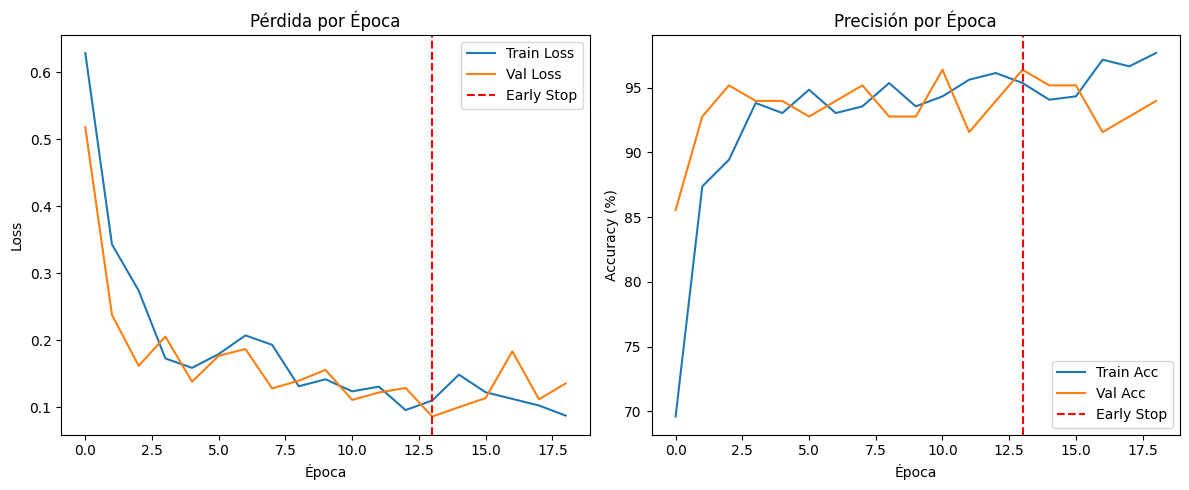

In [5]:
import copy
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── HISTORIAL DE MÉTRICAS ──────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   []
}

# ── MODELO, OPTIMIZADOR Y CRITERIO ────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

final_model = FaceClassifier(
    hidden_layers=best_params['layers'],
    dropout_rate=best_params['dropout']
).to(device)

optimizer = optim.Adam(final_model.classifier.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

# ── CONFIGURACIÓN EARLY STOPPING ──────────────────────────────────
epochs        = 50
patience      = 5
counter       = 0
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(final_model.state_dict())

# ── BUCLE DE ENTRENAMIENTO ─────────────────────────────────────────
pbar_epochs = tqdm(range(epochs), desc="Entrenamiento")

for epoch in pbar_epochs:

    # ── FASE DE ENTRENAMIENTO ──────────────────────────────────────
    final_model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

    # ── FASE DE VALIDACIÓN ─────────────────────────────────────────
    final_model.eval()
    val_loss_total, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = final_model(imgs)
            loss = criterion(outputs, labels)

            val_loss_total += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    # ── GUARDAR MÉTRICAS ───────────────────────────────────────────
    avg_train_loss = train_loss     / len(train_loader)
    avg_val_loss   = val_loss_total / len(val_loader)
    train_acc      = 100. * train_correct / train_total
    val_acc        = 100. * val_correct   / val_total

    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(avg_val_loss)
    history['val_acc'].append(val_acc)

    # ── EARLY STOPPING ─────────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss  = avg_val_loss
        best_model_wts = copy.deepcopy(final_model.state_dict())
        counter        = 0
        tag            = "✔"
    else:
        counter += 1
        tag      = f"✘ {counter}/{patience}"

    pbar_epochs.set_postfix(
        t_acc=f"{train_acc:.1f}%",
        v_acc=f"{val_acc:.1f}%",
        v_loss=f"{avg_val_loss:.4f}",
        es=tag
    )

    if counter >= patience:
        print(f"\n[Early Stopping] Parado en época {epoch + 1}. "
              f"Sin mejora por {patience} épocas. "
              f"Mejor val_loss: {best_val_loss:.4f}")
        break

# ── RESTAURAR MEJORES PESOS ────────────────────────────────────────
final_model.load_state_dict(best_model_wts)
print(f"✔ Pesos restaurados al mejor modelo (val_loss = {best_val_loss:.4f})")

# ── GRÁFICAS ───────────────────────────────────────────────────────
epochs_ran = len(history['train_loss'])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.axvline(epochs_ran - 1 - patience, color='red', linestyle='--', label='Early Stop')
plt.title('Pérdida por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'],   label='Val Acc')
plt.axvline(epochs_ran - 1 - patience, color='red', linestyle='--', label='Early Stop')
plt.title('Precisión por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()


--- Reporte de Métricas ---
              precision    recall  f1-score   support

        Otro       1.00      0.97      0.99        35
          Yo       0.98      1.00      0.99        49

    accuracy                           0.99        84
   macro avg       0.99      0.99      0.99        84
weighted avg       0.99      0.99      0.99        84



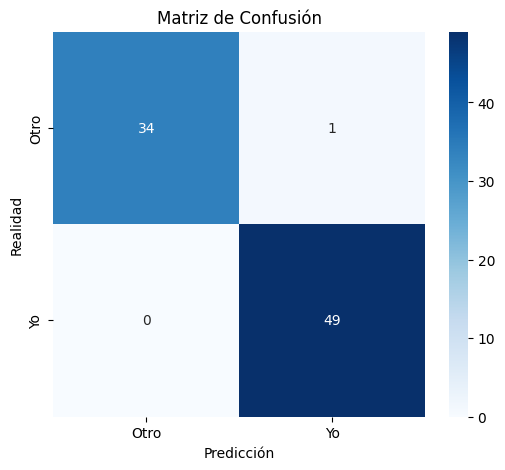

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # 1. Reporte de Clasificación
    print("\n--- Reporte de Métricas ---")
    print(classification_report(all_labels, all_preds, target_names=['Otro', 'Yo']))
    
    # 2. Matriz de Confusión
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Otro', 'Yo'], yticklabels=['Otro', 'Yo'])
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.title('Matriz de Confusión')
    plt.show()

# Ejecutar evaluación sobre el TEST SET
evaluate_model(final_model, test_loader)

In [7]:
torch.save(final_model.state_dict(), 'model.pth')
print("Modelo guardado como 'model.pth'")

Modelo guardado como 'model.pth'


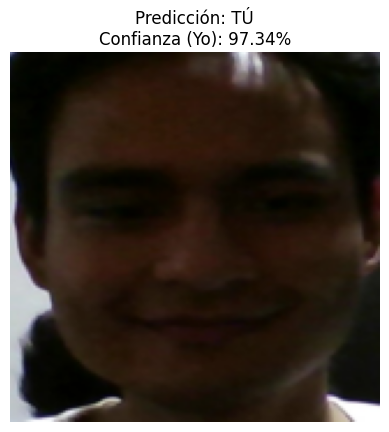

Resultado final: TÚ (97.34%)


In [15]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import transforms
from facenet_pytorch import MTCNN

def reconocer_cara(ruta_imagen, modelo, device):
    # 1. Configurar preprocesamiento
    # Debe ser el mismo que usamos en el entrenamiento
    mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=False)
    
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    # 2. Cargar imagen y detectar cara
    img = Image.open(ruta_imagen).convert('RGB')
    face = mtcnn(img)
    
    if face is None:
        return "No se detectó ninguna cara en la imagen."

    # 3. Preparar el tensor para el modelo
    # El tensor sale de MTCNN como (3, 160, 160), necesitamos (1, 3, 160, 160)
    face_pil = transforms.ToPILImage()(face.byte()) # Convertimos a PIL para aplicar el transform de normalización
    face_tensor = transform(face_pil).unsqueeze(0).to(device)
    
    # 4. Inferencia
    modelo.eval()
    with torch.no_grad():
        outputs = modelo(face_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        prob_yo = probabilities[0][1].item() * 100 # Clase 1 es 'true' (yo)
        prob_otro = probabilities[0][0].item() * 100
        
        _, predicted = torch.max(outputs, 1)
        clase = "TÚ" if predicted.item() == 1 else "OTRA PERSONA"

    # 5. Mostrar resultado
    plt.imshow(face_pil)
    plt.title(f"Predicción: {clase}\nConfianza (Yo): {prob_yo:.2f}%")
    plt.axis('off')
    plt.show()
    
    return clase, prob_yo

# --- USO DEL CÓDIGO ---

# Asegúrate de que el modelo esté cargado (si no lo tienes en memoria)
# final_model.load_state_dict(torch.load('mi_cara_model.pth'))

ruta = "image.png"  # Pon aquí la ruta de una foto que no haya visto el modelo
resultado, confianza = reconocer_cara(ruta, final_model, device)
print(f"Resultado final: {resultado} ({confianza:.2f}%)")